# Лабораторная 4: классификация цветов автомобилей (DVM)

Что делаем по ТЗ:
1. Дообучаем 2 предобученные модели: одна из ImageNet, вторая не из ImageNet.
2. Обучаем свою модель с нуля и объясняем выбор архитектуры.
3. Оцениваем качество по F1_macro.
4. Сравниваем результаты и делаем вывод.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Подготовка данных DVM

Источник: https://deepvisualmarketing.github.io/

Рекомендованная часть для этой лабы: "Quality checked front-view images" (около 730 MB).

Ожидаемая структура изображений внутри DVM: папки вида `Brand-Model-Year-Colour` и изображения внутри них.
Цвет извлекаем из имени папки (последний сегмент после `-`) или из имени файла для confirmed_fronts.

Для стабильного и честного сравнения моделей используется очищенный поднабор наиболее частых цветов:
- удаляются шумные метки (`unlisted`, `multicolour`, ...),
- берутся top-N частых цветов с достаточным числом примеров,
- выборка балансируется по классам.

In [2]:
# Путь к изображениям DVM (измени при необходимости)
CANDIDATE_DATA_ROOTS = [Path('data/confirmed_fronts'), Path('lab-4/data/confirmed_fronts'), Path('data'), Path('lab-4/data')]
DATA_ROOT = next((p for p in CANDIDATE_DATA_ROOTS if p.exists()), CANDIDATE_DATA_ROOTS[0])
print('Используем DATA_ROOT =', DATA_ROOT.resolve())

# Делаем более чистый и стабильный поднабор классов
EXCLUDED_COLORS = {'unlisted', 'multicolour', 'unknown', 'other'}
TARGET_COLOR_COUNT = 6
MIN_SAMPLES_PER_CLASS = 500
MAX_SAMPLES_PER_CLASS = 1200

# Гиперпараметры
BATCH_SIZE = 32
NUM_WORKERS = 0  # multiprocessing workers в Jupyter на Python 3.14 могут падать, поэтому 0
EPOCHS_PRETRAINED = 7
EPOCHS_SCRATCH = 10
EARLY_STOPPING_PATIENCE = 3

Используем DATA_ROOT = /home/flicky/itmo/mlcv-itmo/lab-4/data/confirmed_fronts


In [3]:
def normalize_color_name(raw: str) -> str:
    raw = raw.strip().lower().replace(' ', '_')
    mapping = {
        'gray': 'grey',
        'charcoal': 'grey',
        'dark_grey': 'grey',
        'light_grey': 'grey',
        'dark_blue': 'blue',
        'light_blue': 'blue',
        'dark_red': 'red',
        'maroon': 'red',
        'dark_green': 'green',
        'light_green': 'green',
        'dark_silver': 'silver',
        'light_silver': 'silver'
    }
    return mapping.get(raw, raw)

def extract_color_from_path(path: Path) -> str:
    # confirmed_fronts: Brand/Year/Brand$$Model$$Year$$Color$$...jpg
    stem_parts = path.stem.split('$$')
    if len(stem_parts) >= 4:
        return normalize_color_name(stem_parts[3])

    # fallback для структуры Brand-Model-Year-Colour
    folder_parts = path.parent.name.split('-')
    candidate = folder_parts[-1] if folder_parts else path.parent.name
    return normalize_color_name(candidate)

def collect_dvm_images(root: Path) -> pd.DataFrame:
    if not root.exists():
        raise FileNotFoundError(
            f'Папка с данными не найдена: {root}. Скачай DVM front-view и распакуй в эту папку.'
        )

    image_paths = []
    for ext in ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp'):
        image_paths.extend(root.rglob(ext))

    records = []
    bad_files = 0
    for p in image_paths:
        # Пропускаем поврежденные изображения, чтобы DataLoader не падал посреди обучения
        try:
            with Image.open(p) as img:
                img.verify()
        except (UnidentifiedImageError, OSError):
            bad_files += 1
            continue

        color = extract_color_from_path(p)
        records.append({'path': str(p), 'color': color})

    df = pd.DataFrame(records)
    if len(df) == 0:
        raise FileNotFoundError(
            f'Изображения не найдены в {root}. Скачай DVM front-view и распакуй в эту папку.'
        )

    if bad_files > 0:
        print(f'Пропущено поврежденных файлов: {bad_files}')

    return df

df_all = collect_dvm_images(DATA_ROOT)
print('Всего изображений:', len(df_all))
print('Всего сырых цветовых меток:', df_all['color'].nunique())
df_all['color'].value_counts().head(15)

Всего изображений: 61827
Всего сырых цветовых меток: 22


color
black       14317
grey         9474
white        9395
blue         8483
silver       7770
red          6121
unlisted     1516
brown         911
green         777
yellow        667
beige         600
orange        559
purple        362
bronze        329
gold          217
Name: count, dtype: int64

In [4]:
# Чистим шумные метки и оставляем наиболее стабильные частые цвета
df_work = df_all.copy()
df_work = df_work[~df_work['color'].isin(EXCLUDED_COLORS)].copy()

counts = df_work['color'].value_counts()
valid_colors = counts[counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
valid_counts = counts.loc[valid_colors].sort_values(ascending=False)
top_colors = valid_counts.head(TARGET_COLOR_COUNT).index.tolist()

df = df_work[df_work['color'].isin(top_colors)].copy()

balanced_parts = []
for color, grp in df.groupby('color'):
    grp = grp.sample(n=min(len(grp), MAX_SAMPLES_PER_CLASS), random_state=SEED)
    balanced_parts.append(grp)
df = pd.concat(balanced_parts).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print('После фильтрации/баланса:')
print('Изображений:', len(df))
print('Классов:', df['color'].nunique())
print('Классы:', sorted(df['color'].unique().tolist()))
df['color'].value_counts()

После фильтрации/баланса:
Изображений: 7200
Классов: 6
Классы: ['black', 'blue', 'grey', 'red', 'silver', 'white']


color
grey      1200
red       1200
blue      1200
black     1200
white     1200
silver    1200
Name: count, dtype: int64

In [5]:
# Train/val/test с стратификацией
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['color']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['color']
)

le = LabelEncoder()
le.fit(train_df['color'])

for part in (train_df, val_df, test_df):
    part['label'] = le.transform(part['color'])

num_classes = len(le.classes_)
print(f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}, classes={num_classes}')
print('Классы:', list(le.classes_))

train=5040, val=1080, test=1080, classes=6
Классы: ['black', 'blue', 'grey', 'red', 'silver', 'white']


In [6]:
class CarColorDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        label = int(row['label'])
        return image, label

## Архитектуры

- **Model A (ImageNet):** EfficientNet-B0 (`torchvision`) — легкая и стабильная для fine-tuning.
- **Model B (не ImageNet):** OpenCLIP RN50 (OpenAI CLIP pretrain) — предобучение на web-scale image-text данных.
- **Model C (с нуля):** компактная CNN из 4 блоков Conv-BN-ReLU-MaxPool + Dropout + FC.

Почему такая своя архитектура:
- задача цветовой классификации проще объектной,
- важно не переусложнить сеть и не переобучиться,
- блоки со свертками хорошо вытаскивают локальные цвето-текстурные признаки.

In [7]:
def build_efficientnet_imagenet(n_classes: int):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    # Размораживаем только поздние блоки + классификатор
    for p in model.features.parameters():
        p.requires_grad = False
    for p in model.features[-2:].parameters():
        p.requires_grad = True

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, n_classes)
    )
    return model

class OpenClipColorHead(nn.Module):
    def __init__(self, n_classes: int, clip_model_name='RN50', clip_pretrained='openai'):
        super().__init__()
        try:
            import open_clip
        except ImportError as exc:
            raise RuntimeError(
                'Для эксперимента с OpenCLIP установи пакет open_clip_torch: pip install open_clip_torch'
            ) from exc

        model, _, _ = open_clip.create_model_and_transforms(
            clip_model_name,
            pretrained=clip_pretrained
        )
        self.visual = model.visual

        # Частичный fine-tuning для лучшей адаптации
        for p in self.visual.parameters():
            p.requires_grad = False

        if hasattr(model.visual, 'output_dim'):
            embed_dim = model.visual.output_dim
        elif hasattr(model, 'text_projection'):
            embed_dim = model.text_projection.shape[1]
        else:
            raise RuntimeError('Не удалось определить размер эмбеддинга для OpenCLIP visual encoder')

        self.dropout = nn.Dropout(0.3)
        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, x):
        feats = self.visual(x)
        if isinstance(feats, tuple):
            feats = feats[0]
        feats = self.dropout(feats)
        return self.head(feats)

def build_openclip_other(n_classes: int):
    return OpenClipColorHead(n_classes)

class SmallColorCNN(nn.Module):
    def __init__(self, n_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def build_scratch_cnn(n_classes: int):
    return SmallColorCNN(n_classes)

In [8]:
def make_loaders(train_tf, val_tf):
    train_ds = CarColorDataset(train_df, transform=train_tf)
    val_ds = CarColorDataset(val_df, transform=val_tf)
    test_ds = CarColorDataset(test_df, transform=val_tf)

    # Сэмплер для более ровного обучения при остаточном дисбалансе
    class_counts = train_df['label'].value_counts().sort_index().values.astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1.0)
    sample_weights = train_df['label'].map(lambda y: inv_freq[int(y)]).values
    train_sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return train_loader, val_loader, test_loader

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)

        pred = torch.argmax(logits, dim=1)
        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(pred.cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    f1m = f1_score(y_true, y_pred, average='macro')
    return avg_loss, f1m, y_true, y_pred

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

def run_experiment(name, build_model_fn, train_tf, val_tf, epochs, lr, weight_decay):
    print(f'\n===== {name} =====')

    train_loader, val_loader, test_loader = make_loaders(train_tf, val_tf)

    model = build_model_fn(num_classes).to(device)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    trainable_count = sum(p.numel() for p in trainable_params)
    print(f'Параметры: trainable={trainable_count:,} / total={total_params:,}')

    # Взвешенная CE + небольшое label smoothing
    train_counts = train_df['label'].value_counts().sort_index().values
    class_weights = (train_counts.sum() / (num_classes * train_counts)).astype(np.float32)
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, device=device),
        label_smoothing=0.03
    )

    optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'val_f1_macro': []}
    best_f1 = -1.0
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1_macro'].append(val_f1)

        print(f'Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_f1_macro={val_f1:.4f}')

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= EARLY_STOPPING_PATIENCE:
                print('Early stopping triggered.')
                break

        scheduler.step()

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_f1, y_true, y_pred = evaluate(model, test_loader, criterion)
    report = classification_report(y_true, y_pred, target_names=le.classes_, digits=4, zero_division=0)

    print(f'[TEST] loss={test_loss:.4f} | F1_macro={test_f1:.4f}')

    return {
        'name': name,
        'history': history,
        'test_loss': test_loss,
        'test_f1_macro': test_f1,
        'y_true': y_true,
        'y_pred': y_pred,
        'report': report
    }

In [9]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

clip_mean = [0.48145466, 0.4578275, 0.40821073]
clip_std = [0.26862954, 0.26130258, 0.27577711]

train_tf_imagenet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_tf_imagenet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_tf_clip = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.12, hue=0.015),
    transforms.ToTensor(),
    transforms.Normalize(clip_mean, clip_std),
])

val_tf_clip = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(clip_mean, clip_std),
])

train_tf_scratch = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_tf_scratch = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

In [10]:
results = {}

results['EfficientNet_B0_ImageNet'] = run_experiment(
    name='EfficientNet_B0_ImageNet',
    build_model_fn=build_efficientnet_imagenet,
    train_tf=train_tf_imagenet,
    val_tf=val_tf_imagenet,
    epochs=EPOCHS_PRETRAINED,
    lr=2e-4,
    weight_decay=1e-4
)

try:
    results['OpenCLIP_RN50_OpenAI'] = run_experiment(
        name='OpenCLIP_RN50_OpenAI',
        build_model_fn=build_openclip_other,
        train_tf=train_tf_clip,
        val_tf=val_tf_clip,
        epochs=EPOCHS_PRETRAINED,
        lr=1e-4,
        weight_decay=5e-5
    )
except Exception as exc:
    print(f'OpenCLIP experiment skipped: {exc}')

results['SmallColorCNN_Scratch'] = run_experiment(
    name='SmallColorCNN_Scratch',
    build_model_fn=build_scratch_cnn,
    train_tf=train_tf_scratch,
    val_tf=val_tf_scratch,
    epochs=EPOCHS_SCRATCH,
    lr=5e-4,
    weight_decay=1e-4
)


===== EfficientNet_B0_ImageNet =====
Параметры: trainable=1,137,078 / total=4,015,234
Epoch 01/7 | train_loss=1.0687 | val_loss=0.7440 | val_f1_macro=0.7958
Epoch 02/7 | train_loss=0.7206 | val_loss=0.6625 | val_f1_macro=0.8207
Epoch 03/7 | train_loss=0.6574 | val_loss=0.6346 | val_f1_macro=0.8185
Epoch 04/7 | train_loss=0.6208 | val_loss=0.6253 | val_f1_macro=0.8324
Epoch 05/7 | train_loss=0.5910 | val_loss=0.6013 | val_f1_macro=0.8392
Epoch 06/7 | train_loss=0.5567 | val_loss=0.5982 | val_f1_macro=0.8381
Epoch 07/7 | train_loss=0.5597 | val_loss=0.5982 | val_f1_macro=0.8388
[TEST] loss=0.6101 | F1_macro=0.8185

===== OpenCLIP_RN50_OpenAI =====


/home/flicky/itmo/mlcv-itmo/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/flicky/itmo/mlcv-itmo/.venv/lib64/python3.14/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Параметры: trainable=6,150 / total=38,323,046
Epoch 01/7 | train_loss=1.7764 | val_loss=1.7640 | val_f1_macro=0.2498
Epoch 02/7 | train_loss=1.7489 | val_loss=1.7403 | val_f1_macro=0.3973
Epoch 03/7 | train_loss=1.7255 | val_loss=1.7183 | val_f1_macro=0.4721
Epoch 04/7 | train_loss=1.7053 | val_loss=1.7030 | val_f1_macro=0.5150
Epoch 05/7 | train_loss=1.6909 | val_loss=1.6923 | val_f1_macro=0.5122
Epoch 06/7 | train_loss=1.6846 | val_loss=1.6888 | val_f1_macro=0.5162
Epoch 07/7 | train_loss=1.6805 | val_loss=1.6874 | val_f1_macro=0.5113
[TEST] loss=1.6840 | F1_macro=0.4955

===== SmallColorCNN_Scratch =====
Параметры: trainable=423,046 / total=423,046
Epoch 01/10 | train_loss=1.1861 | val_loss=1.0388 | val_f1_macro=0.6258
Epoch 02/10 | train_loss=1.0057 | val_loss=0.9162 | val_f1_macro=0.6761
Epoch 03/10 | train_loss=0.9283 | val_loss=0.9762 | val_f1_macro=0.6412
Epoch 04/10 | train_loss=0.8892 | val_loss=0.8387 | val_f1_macro=0.7130
Epoch 05/10 | train_loss=0.8402 | val_loss=0.9168 | 

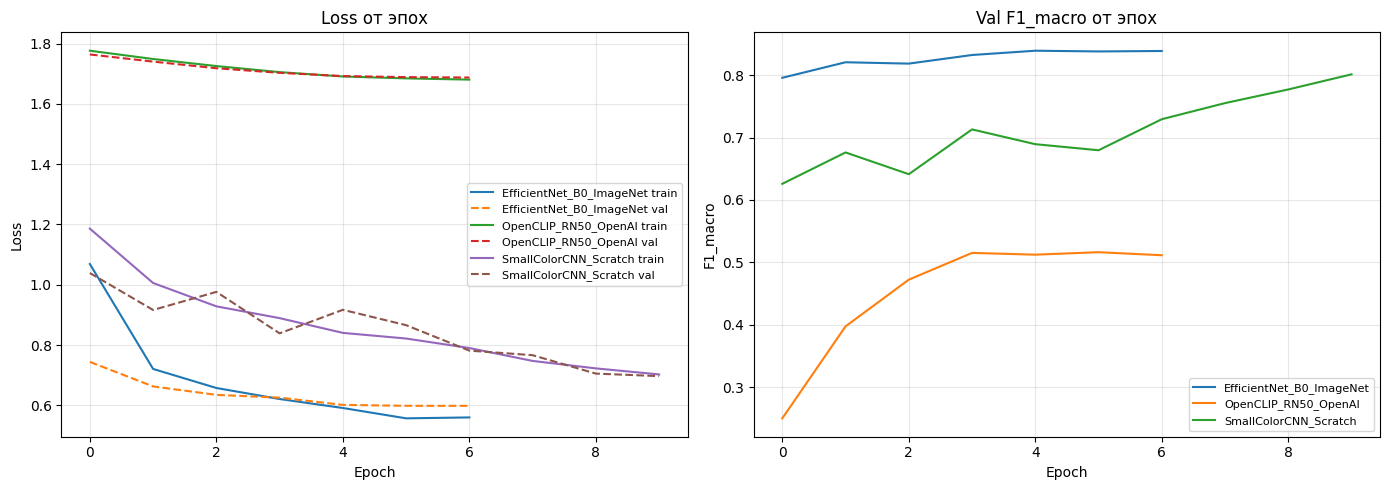

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, pack in results.items():
    h = pack['history']
    axes[0].plot(h['train_loss'], label=f'{name} train')
    axes[0].plot(h['val_loss'], '--', label=f'{name} val')
    axes[1].plot(h['val_f1_macro'], label=name)

axes[0].set_title('Loss от эпох')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_title('Val F1_macro от эпох')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1_macro')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
summary = pd.DataFrame([
    {'model': name, 'test_loss': pack['test_loss'], 'test_f1_macro': pack['test_f1_macro']}
    for name, pack in results.items()
]).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)

summary

,model,test_loss,test_f1_macro
0,EfficientNet_B0_ImageNet,0.610053,0.818491
1,SmallColorCNN_Scratch,0.657334,0.810710
2,OpenCLIP_RN50_OpenAI,1.683987,0.495503


In [13]:
best_model_name = summary.iloc[0]['model']
best_f1 = summary.iloc[0]['test_f1_macro']

print('Лучший результат:')
print(f'  {best_model_name}: F1_macro = {best_f1:.4f}')

print('\nИнтерпретация F1_macro:')
print('- F1_macro усредняет F1 по всем цветам одинаково, поэтому честно показывает качество даже при дисбалансе классов.')
print('- Если F1_macro заметно ниже accuracy, модель, скорее всего, хуже работает на редких цветах.')

print('\nКраткий вывод:')
print('- Предобученные модели обычно лучше стартуют и дают выше F1_macro на малых/средних выборках.')
print('- Модель с нуля может догонять только при достаточном объеме данных и аккуратной регуляризации.')
print('- Модель не из ImageNet (OpenCLIP) показывает, насколько переносится web-scale предобучение на задачу цвета авто.')

Лучший результат:
  EfficientNet_B0_ImageNet: F1_macro = 0.8185

Интерпретация F1_macro:
- F1_macro усредняет F1 по всем цветам одинаково, поэтому честно показывает качество даже при дисбалансе классов.
- Если F1_macro заметно ниже accuracy, модель, скорее всего, хуже работает на редких цветах.

Краткий вывод:
- Предобученные модели обычно лучше стартуют и дают выше F1_macro на малых/средних выборках.
- Модель с нуля может догонять только при достаточном объеме данных и аккуратной регуляризации.
- Модель не из ImageNet (OpenCLIP) показывает, насколько переносится web-scale предобучение на задачу цвета авто.


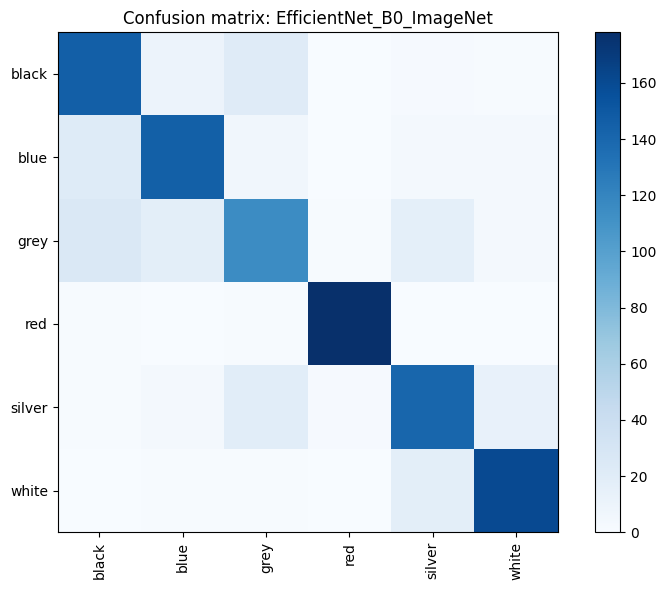

              precision    recall  f1-score   support

       black     0.7449    0.8111    0.7766       180
        blue     0.8146    0.8056    0.8101       180
        grey     0.7055    0.6389    0.6706       180
         red     0.9834    0.9889    0.9861       180
      silver     0.7790    0.7833    0.7812       180
       white     0.8840    0.8889    0.8864       180

    accuracy                         0.8194      1080
   macro avg     0.8186    0.8194    0.8185      1080
weighted avg     0.8186    0.8194    0.8185      1080



In [14]:
# Опционально: confusion matrix для лучшей модели
best_pack = results[best_model_name]
cm = confusion_matrix(best_pack['y_true'], best_pack['y_pred'])

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion matrix: {best_model_name}')
plt.colorbar()
plt.xticks(range(num_classes), le.classes_, rotation=90)
plt.yticks(range(num_classes), le.classes_)
plt.tight_layout()
plt.show()

print(best_pack['report'])